In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. read the two DE tables ---
pbs = pd.read_csv("../results/DGE/PBS-wt-sig.csv", index_col=0)
br  = pd.read_csv("../results/DGE/BRICHOS-wt-sig.csv", index_col=0)


In [16]:
pbs.columns = pbs.columns.str.lower()
br.columns = br.columns.str.lower()

In [18]:
pbs

,basemean,log2foldchange,lfcse,stat,pvalue,padj
Cst7,2191.122062,6.853090,0.341048,20.094185,8.296496e-90,1.223484e-85
Itgax,108.917047,5.180247,0.883919,5.860548,4.613431e-09,7.559363e-07
Ccl3,176.201250,5.136483,0.669090,7.676816,1.630915e-14,5.726453e-12
Fgr,44.606099,3.462944,0.793325,4.365100,1.270646e-05,8.254718e-04
Ccl6,1145.303544,3.417958,0.175045,19.526122,6.585409e-85,4.855751e-81
...,...,...,...,...,...,...
Chst9,47.456154,-1.555222,0.370814,-4.194080,2.739807e-05,1.518945e-03
Anxa8,21.637365,-1.864222,0.546003,-3.414309,6.394392e-04,1.756017e-02
Ngfr,125.094761,-1.928667,0.526970,-3.659920,2.522936e-04,8.922240e-03
Crb1,62.865879,-2.022249,0.582556,-3.471338,5.178709e-04,1.503355e-02


In [19]:
br

,basemean,log2foldchange,lfcse,stat,pvalue,padj
Cst7,1273.491760,6.722796,0.380292,17.677998,6.195700e-70,1.036417e-65
Itgax,80.214678,5.388952,0.968180,5.566062,2.605606e-08,2.075551e-05
Ccl3,94.315942,4.883393,0.805879,6.059711,1.363662e-09,1.267296e-06
Ccl6,684.409196,3.303398,0.248282,13.305015,2.164492e-40,1.810381e-36
Cxcl5,119.850282,2.853963,0.720415,3.961554,7.446350e-05,3.038111e-02
Cd52,605.266282,1.976794,0.238385,8.292425,1.109624e-16,3.712356e-13
Tyrobp,1743.467914,1.883567,0.172795,10.900615,1.144809e-27,6.383458e-24
Gfap,9912.419401,1.673474,0.196814,8.502817,1.850440e-17,7.738541e-14
Myo1f,261.939308,1.600347,0.313728,5.101065,3.377476e-07,2.354101e-04
C3ar1,322.936474,1.596137,0.302179,5.282083,1.277231e-07,9.711598e-05


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_94233/677491185.py:79: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


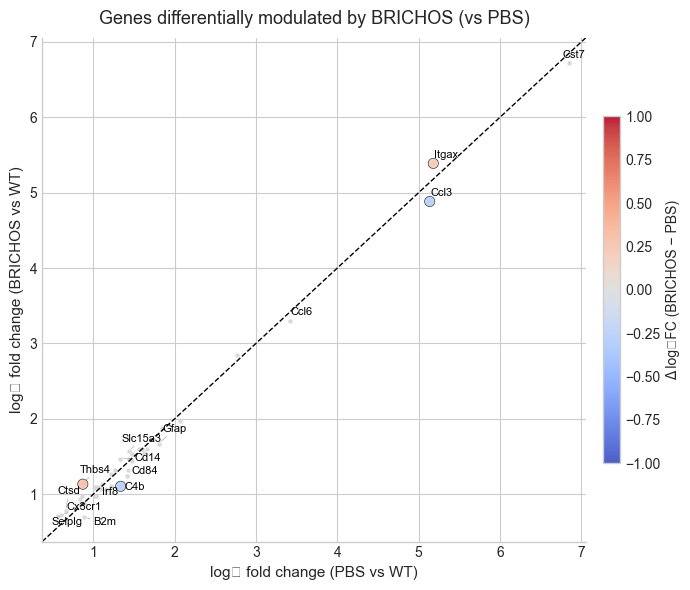

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# df already built as before, with columns:
# log2FC_pbs, log2FC_brichos, delta

delta_thr = 0.2
df["abs_delta"] = df["delta"].abs()

# 1) background = everything, but very faint
fig, ax = plt.subplots(figsize=(7, 6))
plt.style.use("seaborn-v0_8-whitegrid")

# background scatter
ax.scatter(
    df["log2FC_pbs"],
    df["log2FC_brichos"],
    s=10,
    c="#d9d9d9",
    alpha=1,
    lw=0,
    zorder=1,
)

# 2) interesting points = |delta| > thr, colored by delta
mask_int = df["abs_delta"] >= delta_thr
vmin, vmax = -df["abs_delta"].max(), df["abs_delta"].max()  # symmetric
sc = ax.scatter(
    df.loc[mask_int, "log2FC_pbs"],
    df.loc[mask_int, "log2FC_brichos"],
    s=55,
    c=df.loc[mask_int, "delta"],
    cmap="coolwarm",
    vmin=-1.0,  # you can tune this
    vmax=1.0,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.4,
    zorder=3,
)

# 3) diagonal
mn = min(df["log2FC_pbs"].min(), df["log2FC_brichos"].min()) - 0.2
mx = max(df["log2FC_pbs"].max(), df["log2FC_brichos"].max()) + 0.2
ax.plot([mn, mx], [mn, mx], "k--", lw=1)
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)

# 4) label top |delta|
topN = 15
top_genes = df.sort_values("abs_delta", ascending=False).head(topN)
texts = []
for gene, row in top_genes.iterrows():
    texts.append(
        ax.text(
            row["log2FC_pbs"],
            row["log2FC_brichos"],
            gene,
            fontsize=8,
            ha="left",
            va="bottom",
            color="black",
            zorder=5,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

# 5) colorbar
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label("Δ log₂FC (BRICHOS − PBS)", rotation=90)

# 6) cosmetics
ax.set_xlabel("log₂ fold change (PBS vs WT)", fontsize=11)
ax.set_ylabel("log₂ fold change (BRICHOS vs WT)", fontsize=11)
ax.set_title("Genes differentially modulated by BRICHOS (vs PBS)", fontsize=13, pad=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()